# Synthetic Data & Applications: What `CEModel` Expects as Input

This notebook is for a reader who has **not yet touched real data** and wants
to understand, concretely, what a `CEModel` (`conditional_embedding_model.general`)
expects as input and what a correct result looks like, before pointing it at
anything real. It:

1. Generates a fully synthetic toy dataset with a **known, planted** ground-truth
   affinity structure (reusing `make_toy_data` from `general/examples/toy.py`,
   the same generator used by the toy-example smoke test and
   `04_general_cemodel_quickstart.ipynb` — no new generator is written here).
2. Visualizes the raw data itself: what a center input dict and a context
   input dict actually look like, and the planted affinity.
3. Compares the `mlp` encoder's `{"x": ...}` input contract against the
   legacy `legacy_v4_*` encoders' `{"index": ..., "feature": ...}` contract,
   side by side.
4. Trains briefly and visualizes the model's *learned* affinity matrix next
   to the *ground-truth* one, so "expected result" is a concrete picture.
5. Closes with a discussion of what properties data needs to fit this
   framework, and other applications beyond cooperative grasping that fit
   the same dict-in/affinity-out contract.

No PyBullet, no `CoopGrasping-v6_dataset.pkl`, no GPU required — everything
here runs on CPU in well under a minute.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from conditional_embedding_model.general import (
    CEModelConfig, EncoderConfig, ScorerConfig, build_model, ContrastiveBCELoss, Trainer,
)
from conditional_embedding_model.general.examples.toy import make_toy_data

torch.manual_seed(0)
np.random.seed(0)

## 1. Generate the synthetic toy dataset

`make_toy_data` plants a rank-`latent_dim` affinity
`a[i, j] = ẑ_c[i] · ẑ_x[i, j]` between L2-normalized latent vectors `z_c`
(one per center) and `z_x` (`K` per center, one per candidate slot). The
model never sees these latents directly — only noisy linear *observations*
of them (`center_x`, `context_x`), obtained through a shared random lift
matrix `W`. The top-`n_pos` highest-affinity candidates per center are
labeled positive (`label = 1`); a few trailing slots per row are randomly
masked out (`mask = 0`) to exercise variable-length padding, the same way
real grasp-candidate lists are padded to `max_length`.

In [2]:
obs_dim, K, latent_dim, n_pos = 32, 16, 4, 2

train_data, val_data, W = make_toy_data(
    n_centers=512, K=K, latent_dim=latent_dim, obs_dim=obs_dim,
    noise=0.1, n_pos=n_pos, seed=0,
)

print("train_data keys and shapes:")
for k, v in train_data.items():
    print(f"  {k:>10}: {tuple(v.shape)}  dtype={v.dtype}")

train_data keys and shapes:
    center_x: (410, 32)  dtype=torch.float32
   context_x: (410, 16, 32)  dtype=torch.float32
       label: (410, 16)  dtype=torch.float32
        mask: (410, 16)  dtype=torch.float32


## 2. Visualize the raw data

- `center_x`: `[N, obs_dim]` — one observation vector per center.
- `context_x`: `[N, K, obs_dim]` — `K` candidate observation vectors per
  center (the padded slate).
- `label` / `mask`: `[N, K]` — which candidates are positive, and which
  slots are real vs. padding.

We render one sample's context slate as a heatmap (rows = candidate slots,
columns = observation dimensions), with the positive/masked slots called
out, and the full `label`/`mask` grid across the first 40 centers as a
compact table-style image.

center_x[0] (first 8 of 32 dims): [-0.07 -0.42  0.69  0.9   0.24 -0.14  0.05  0.23]


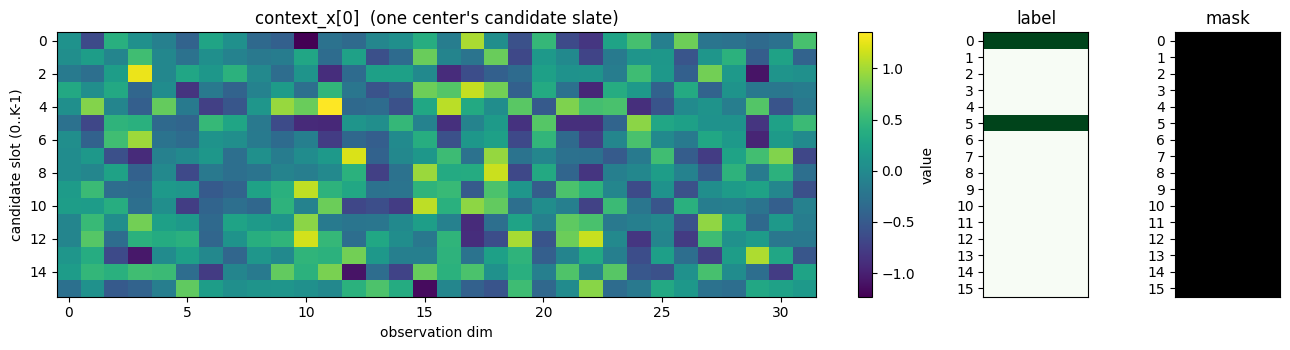

In [3]:
sample_i = 0
context_sample = train_data["context_x"][sample_i]   # [K, obs_dim]
label_sample = train_data["label"][sample_i]          # [K]
mask_sample = train_data["mask"][sample_i]             # [K]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), gridspec_kw={"width_ratios": [4, 0.5, 0.5]})

im = axes[0].imshow(context_sample.numpy(), aspect="auto", cmap="viridis")
axes[0].set_title(f"context_x[{sample_i}]  (one center's candidate slate)")
axes[0].set_xlabel("observation dim")
axes[0].set_ylabel("candidate slot (0..K-1)")
fig.colorbar(im, ax=axes[0], fraction=0.046, label="value")

axes[1].imshow(label_sample.numpy()[:, None], aspect="auto", cmap="Greens", vmin=0, vmax=1)
axes[1].set_title("label")
axes[1].set_xticks([])
axes[1].set_yticks(range(K))

axes[2].imshow(mask_sample.numpy()[:, None], aspect="auto", cmap="Greys", vmin=0, vmax=1)
axes[2].set_title("mask")
axes[2].set_xticks([])
axes[2].set_yticks(range(K))

fig.tight_layout()
print(f"center_x[{sample_i}] (first 8 of {obs_dim} dims): "
      f"{train_data['center_x'][sample_i][:8].numpy().round(2)}")

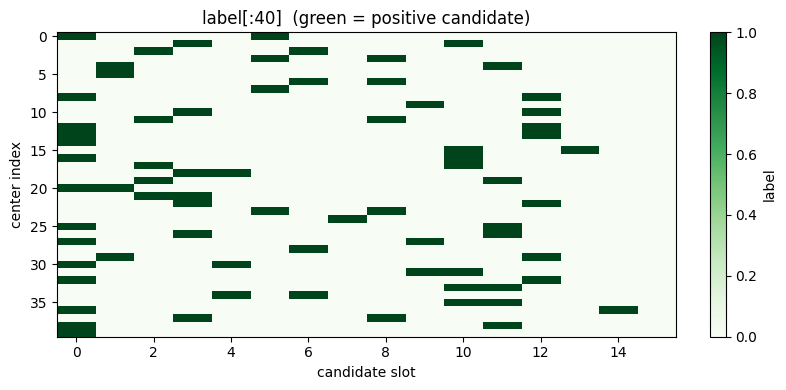

In [4]:
n_show = 40
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(train_data["label"][:n_show].numpy(), aspect="auto", cmap="Greens", vmin=0, vmax=1)
ax.set_title(f"label[:{n_show}]  (green = positive candidate)")
ax.set_xlabel("candidate slot")
ax.set_ylabel("center index")
fig.colorbar(im, ax=ax, fraction=0.046, label="label")
fig.tight_layout()

### The planted ground-truth affinity

The observation vectors are noisy projections of latent unit vectors `z_c`,
`z_x`; the *true* affinity is the cosine similarity of those latents,
computed directly (no model, no noise). This is the structure a well-trained
`CEModel` should recover from the noisy observations alone. We compute it on
a small held-out bank (not `train_data`, which only exposes `label`/`mask`
derived from the top-`n_pos` positions, not the full continuous affinity).

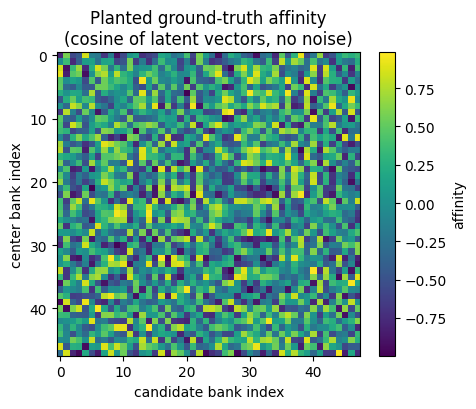

In [5]:
bank_rng = np.random.default_rng(999)
n_bank = 48
z_c_bank = bank_rng.normal(size=(n_bank, latent_dim))
z_c_bank = z_c_bank / np.linalg.norm(z_c_bank, axis=1, keepdims=True)
z_x_bank = bank_rng.normal(size=(n_bank, latent_dim))
z_x_bank = z_x_bank / np.linalg.norm(z_x_bank, axis=1, keepdims=True)
true_affinity = z_c_bank @ z_x_bank.T

center_bank_obs = z_c_bank @ W.T + 0.1 * bank_rng.normal(size=(n_bank, obs_dim))
context_bank_obs = z_x_bank @ W.T + 0.1 * bank_rng.normal(size=(n_bank, obs_dim))

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(true_affinity, cmap="viridis")
ax.set_title("Planted ground-truth affinity\n(cosine of latent vectors, no noise)")
ax.set_xlabel("candidate bank index")
ax.set_ylabel("center bank index")
fig.colorbar(im, ax=ax, fraction=0.046, label="affinity")
fig.tight_layout()

## 3. Two input contracts, side by side

Encoders declare an `input_spec: dict[str, str]` describing the keys they
require. The `mlp` encoder (used above) wants a single flat key:

```python
MLPEncoder.input_spec = {"x": "[B, D_in] or [B, K, D_in] float"}
```

The legacy `legacy_v4_center` / `legacy_v4_context` encoders (wrapping the
paper's frozen `CenterEmbeddingResNetv4`/`ContextEmbeddingResNetv4`) want two
keys instead — an integer index into a shared per-scenario feature block,
plus the feature block itself:

```python
LegacyV4CenterEncoder.input_spec  = {"index": "[B] or [B,1] long", "feature": "[B, F] float"}
LegacyV4ContextEncoder.input_spec = {"index": "[B, K] long",       "feature": "[B, F] float"}
```

Both are valid `dict[str, Tensor]` inputs — `CEModel` doesn't care which
shape a given encoder needs, only that the dict has the keys its `input_spec`
declares. Below we build one example of each, using the real legacy feature
layout from `CLAUDE.md` §3 (`F = 8100 (map) + 8 (object_footprint) + 600
(grasping_approach) = 8708`) so the shapes are the real ones, not invented
placeholders — without actually instantiating the ResNet-backed legacy
encoder (unnecessary network/weights dependency for a shape comparison).

In [6]:
B = 4  # batch size for this illustration

# -- mlp contract: {"x": [B, D_in]} for a center, {"x": [B, K, D_in]} for a context --
mlp_center_inputs = {"x": torch.randn(B, obs_dim)}
mlp_context_inputs = {"x": torch.randn(B, K, obs_dim)}

# -- legacy_v4 contract: {"index": ..., "feature": [B, F]} --
FEATURE_DIMS = {"map": 8100, "object_footprint": 8, "grasping_approach": 600}
F_total = sum(FEATURE_DIMS.values())
legacy_center_inputs = {
    "index": torch.randint(0, 150, (B, 1), dtype=torch.long),
    "feature": torch.randn(B, F_total),
}
legacy_context_inputs = {
    "index": torch.randint(0, 150, (B, K), dtype=torch.long),
    "feature": torch.randn(B, F_total),
}

print("mlp contract:")
print(f"  center_inputs['x']:          {tuple(mlp_center_inputs['x'].shape)}")
print(f"  context_inputs['x']:         {tuple(mlp_context_inputs['x'].shape)}")
print()
print("legacy_v4 contract (F = 8100 map + 8 footprint + 600 grasping_approach = 8708):")
print(f"  center_inputs['index']:      {tuple(legacy_center_inputs['index'].shape)}")
print(f"  center_inputs['feature']:    {tuple(legacy_center_inputs['feature'].shape)}")
print(f"  context_inputs['index']:     {tuple(legacy_context_inputs['index'].shape)}")
print(f"  context_inputs['feature']:   {tuple(legacy_context_inputs['feature'].shape)}")

mlp contract:
  center_inputs['x']:          (4, 32)
  context_inputs['x']:         (4, 16, 32)

legacy_v4 contract (F = 8100 map + 8 footprint + 600 grasping_approach = 8708):
  center_inputs['index']:      (4, 1)
  center_inputs['feature']:    (4, 8708)
  context_inputs['index']:     (4, 16)
  context_inputs['feature']:   (4, 8708)


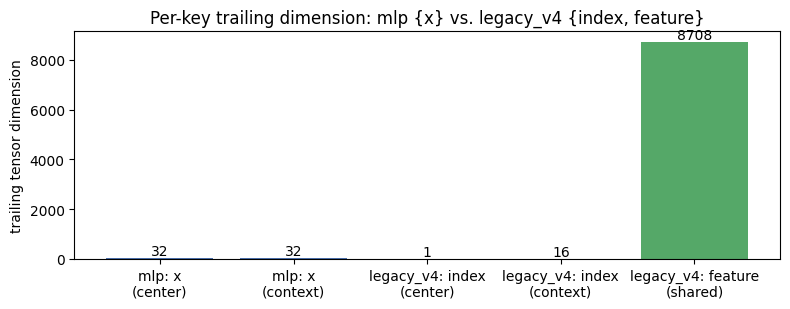

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.2))
labels = ["mlp: x\n(center)", "mlp: x\n(context)", "legacy_v4: index\n(center)",
          "legacy_v4: index\n(context)", "legacy_v4: feature\n(shared)"]
last_dims = [obs_dim, obs_dim, 1, K, F_total]
colors = ["#4c72b0", "#4c72b0", "#dd8452", "#dd8452", "#55a868"]
bars = ax.bar(labels, last_dims, color=colors)
ax.set_ylabel("trailing tensor dimension")
ax.set_title("Per-key trailing dimension: mlp {x} vs. legacy_v4 {index, feature}")
ax.bar_label(bars)
fig.tight_layout()

## 4. Train briefly and compare learned vs. ground-truth affinity

We build a small `mlp`-encoder `CEModel` from config, train it for a few
epochs with `ContrastiveBCELoss` + `Trainer`, then use
`score_all_pairs(center_inputs, context_inputs)` — the full-bank,
no-padding retrieval path — to score the same held-out bank used for the
ground-truth affinity above. Comparing the two heatmaps side by side is what
"the model learned the right structure" looks like concretely: a wrong model
would show a scrambled/uniform heatmap on the right instead of matching the
block/gradient pattern on the left.

In [8]:
from torch.utils.data import DataLoader, Dataset as TorchDataset


class _ToyDataset(TorchDataset):
    def __init__(self, data):
        self.center_x = data["center_x"]
        self.context_x = data["context_x"]
        self.label = data["label"]
        self.mask = data["mask"]

    def __len__(self):
        return self.center_x.shape[0]

    def __getitem__(self, i):
        return self.center_x[i], self.context_x[i], self.label[i], self.mask[i]


def _collate(batch):
    center_x = torch.stack([b[0] for b in batch])
    context_x = torch.stack([b[1] for b in batch])
    label = torch.stack([b[2] for b in batch])
    mask = torch.stack([b[3] for b in batch])
    return (({"x": center_x}, {"x": context_x}), label, mask)


train_loader = DataLoader(_ToyDataset(train_data), batch_size=128, shuffle=True, collate_fn=_collate)
val_loader = DataLoader(_ToyDataset(val_data), batch_size=128, shuffle=False, collate_fn=_collate)

embedding_dim = 8
encoder_params = dict(input_dim=obs_dim, output_dim=embedding_dim,
                       hidden_dims=(64, 64), activation="relu", layer_norm=True)
config = CEModelConfig(
    embedding_dim=embedding_dim,
    center_encoder=EncoderConfig(name="mlp", params=dict(encoder_params)),
    context_encoder=EncoderConfig(name="mlp", params=dict(encoder_params)),
    scorer=ScorerConfig(name="cosine_temperature", params={"temperature": 0.07}),
)
model = build_model(config)
loss_fn = ContrastiveBCELoss(normalization="valid_pairs")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, loss_fn, optimizer, device="cpu", amp=False)

history = trainer.fit(train_loader, val_loader=val_loader, epochs=20)
print(f"train loss: {history['train_loss'][0]:.4f} -> {history['train_loss'][-1]:.4f}")

train loss: 0.3649 -> 0.0489


Spearman(learned, ground-truth) = 0.959


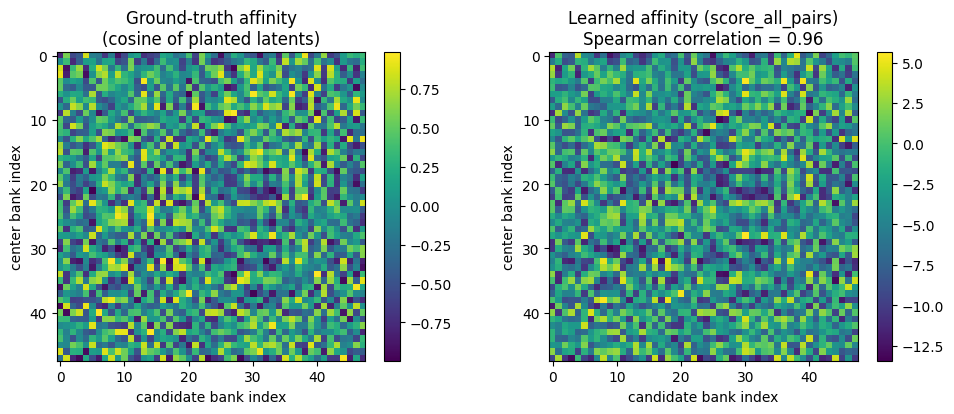

In [9]:
model.eval()
with torch.no_grad():
    v_inputs = {"x": torch.tensor(center_bank_obs, dtype=torch.float32)}
    u_inputs = {"x": torch.tensor(context_bank_obs, dtype=torch.float32)}
    learned_affinity = model.score_all_pairs(v_inputs, u_inputs).numpy()

from scipy.stats import spearmanr
corr, _ = spearmanr(learned_affinity.flatten(), true_affinity.flatten())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
im0 = axes[0].imshow(true_affinity, cmap="viridis")
axes[0].set_title("Ground-truth affinity\n(cosine of planted latents)")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(learned_affinity, cmap="viridis")
axes[1].set_title(f"Learned affinity (score_all_pairs)\nSpearman correlation = {corr:.2f}")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

for ax in axes:
    ax.set_xlabel("candidate bank index")
    ax.set_ylabel("center bank index")
fig.tight_layout()
print(f"Spearman(learned, ground-truth) = {corr:.3f}")
assert corr > 0.5, f'expected the trained model to recover the planted structure, got corr={corr:.3f}'

## 5. Discussion: what data needs to fit this framework, and where else it applies

**What the architecture actually supports** (from `CEModel` in `core.py` and
the encoder/scorer registries — nothing beyond what's implemented):

- **Arbitrary per-key tensors.** An encoder only needs an `input_spec: dict[str, str]`
  and a `forward(inputs: dict) -> Tensor[..., output_dim]`. There is no
  constraint that inputs be images, sequences, or any specific modality —
  `mlp` takes one flat vector key; `legacy_v4_*` takes an index key plus a
  shared feature-block key. A new encoder registered via `@register_encoder`
  can consume whatever keys/shapes it wants, as long as center and context
  encoders agree on `output_dim` (`CEModel.__init__` asserts this).
- **Fixed, padded `K` per center.** The context side is always
  `[B, K, ...]` with an explicit `[B, K]` `mask` marking real vs. padded
  slots — variable-length candidate sets are supported via padding, not
  ragged tensors. `hit_at_k` / `classification_metrics` both respect `mask`.
- **Single- or multi-relation affinity outputs.** The default scorer path
  produces `[B, K]` — one affinity per (center, candidate) pair. Swapping in
  `MultiRelationScorer` (`multi_relation` in the registry) produces
  `[B, K, R]` instead, where labels/masks broadcast over `R` relations and
  metrics report per-relation plus a macro-average. This is a config change
  (`ScorerConfig(name="multi_relation", ...)`), not a code change.
- **Two retrieval modes.** `forward()` scores each center against *its own*
  padded candidate list (training/eval shape, `[B, K]`); `score_all_pairs()`
  scores every center against a shared candidate *bank* (`[B, M]`,
  deployment-style full retrieval, as used above) — both go through the same
  encoders and scorer.

**Applications beyond cooperative grasping that fit the same
dict-in/affinity-out contract:**

1. **General multi-agent task matching.** Replace "robot base position +
   grasp point" with "agent capability vector" and "task requirement
   vector" — the center/context split and masked top-k retrieval directly
   express "which of these K candidate tasks is this agent compatible
   with," independent of the grasping domain.
2. **Recommendation-style compatibility scoring.** A user profile as the
   center, a padded slate of candidate items as the context, and
   `cosine_temperature`/`dot_product` scoring is exactly the two-tower
   retrieval pattern used in production recommenders — `Hit@k` here is the
   same metric as recall@k in that literature.
3. **Sensor/modality fusion compatibility.** If two sensing modalities each
   produce fixed-size embeddings that need to be checked for mutual
   consistency (e.g., "does this LiDAR return match this camera crop"), a
   center encoder for one modality and a context encoder for the other,
   scored by `bilinear` (which explicitly allows the two towers to weight
   dimensions asymmetrically) fits without modification.
4. **Heterogeneous-team pairing.** Any setting with two distinct pools that
   must be paired subject to a compatibility relation — e.g. matching
   specialized workers to task slots with side constraints encoded as the
   `mask` — reduces to the same center/context/scorer/mask shape contract.

The common thread in all four: a **fixed-size embedding per item** on each
side, a **padded candidate set** per query, and a **pairwise affinity**
between the two — the same shape contract `CEModel` implements. Domains that
don't fit this (e.g., variable-cardinality *sets* of centers scored jointly
against each other, or affinities that depend on interactions among
*multiple* context items rather than pairwise center-context comparisons)
would need a different architecture; nothing in `CEModel` claims to cover
those.